# Predicción de Diabetes — Árbol de Decisión

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Carga del dataset

In [2]:
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv'
ruta = '../data/raw/diabetes.csv'
os.makedirs(os.path.dirname(ruta), exist_ok=True)

if not os.path.exists(ruta):
    urllib.request.urlretrieve(url, ruta)

df = pd.read_csv(ruta)
print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. EDA

In [3]:
print(df.info())
print('\nNulos:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Nulos:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         

In [4]:
print('Balance de clases:')
print(df['Outcome'].value_counts())
print(f'\nProporción positivos: {df["Outcome"].mean():.2%}')

Balance de clases:
Outcome
0    500
1    268
Name: count, dtype: int64

Proporción positivos: 34.90%


In [5]:
# Algunas columnas tienen 0 
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_con_ceros:
    n_ceros = (df[col] == 0).sum()
    print(f'{col}: {n_ceros} ceros ({n_ceros/len(df):.1%})')

Glucose: 5 ceros (0.7%)
BloodPressure: 35 ceros (4.6%)
SkinThickness: 227 ceros (29.6%)
Insulin: 374 ceros (48.7%)
BMI: 11 ceros (1.4%)


In [6]:
# Reemplazar ceros imposibles por la mediana según Outcome
df_clean = df.copy()
for col in cols_con_ceros:
    mediana = df_clean[df_clean[col] != 0][col].median()
    df_clean[col] = df_clean[col].replace(0, mediana)

print('Ceros restantes:')
print(df_clean[cols_con_ceros].eq(0).sum())

Ceros restantes:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [8]:
df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


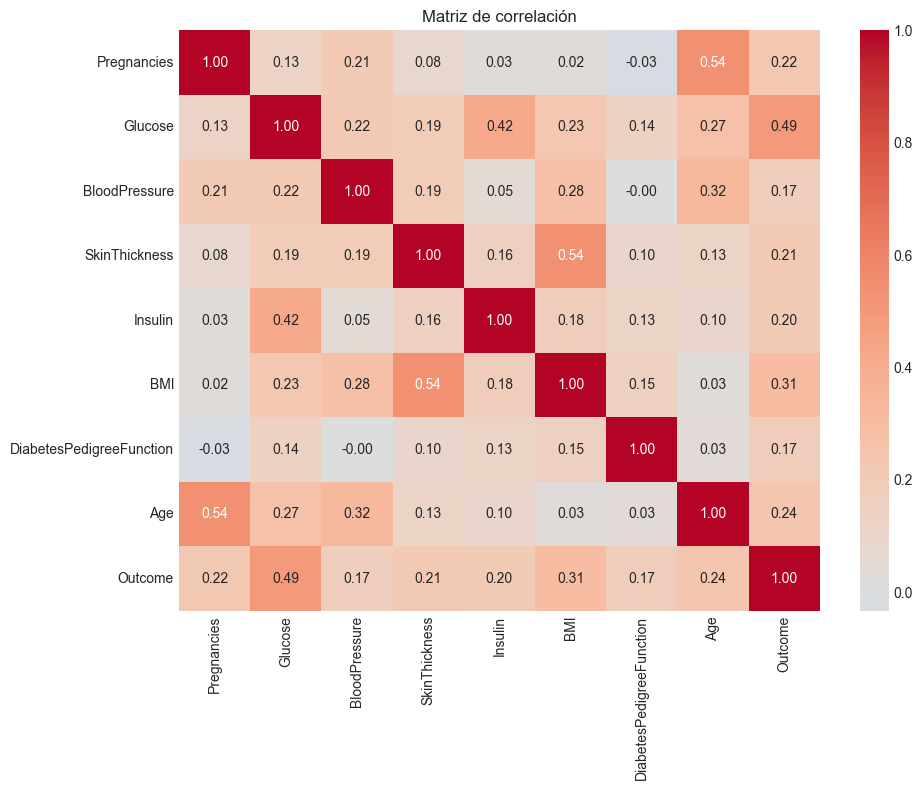

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

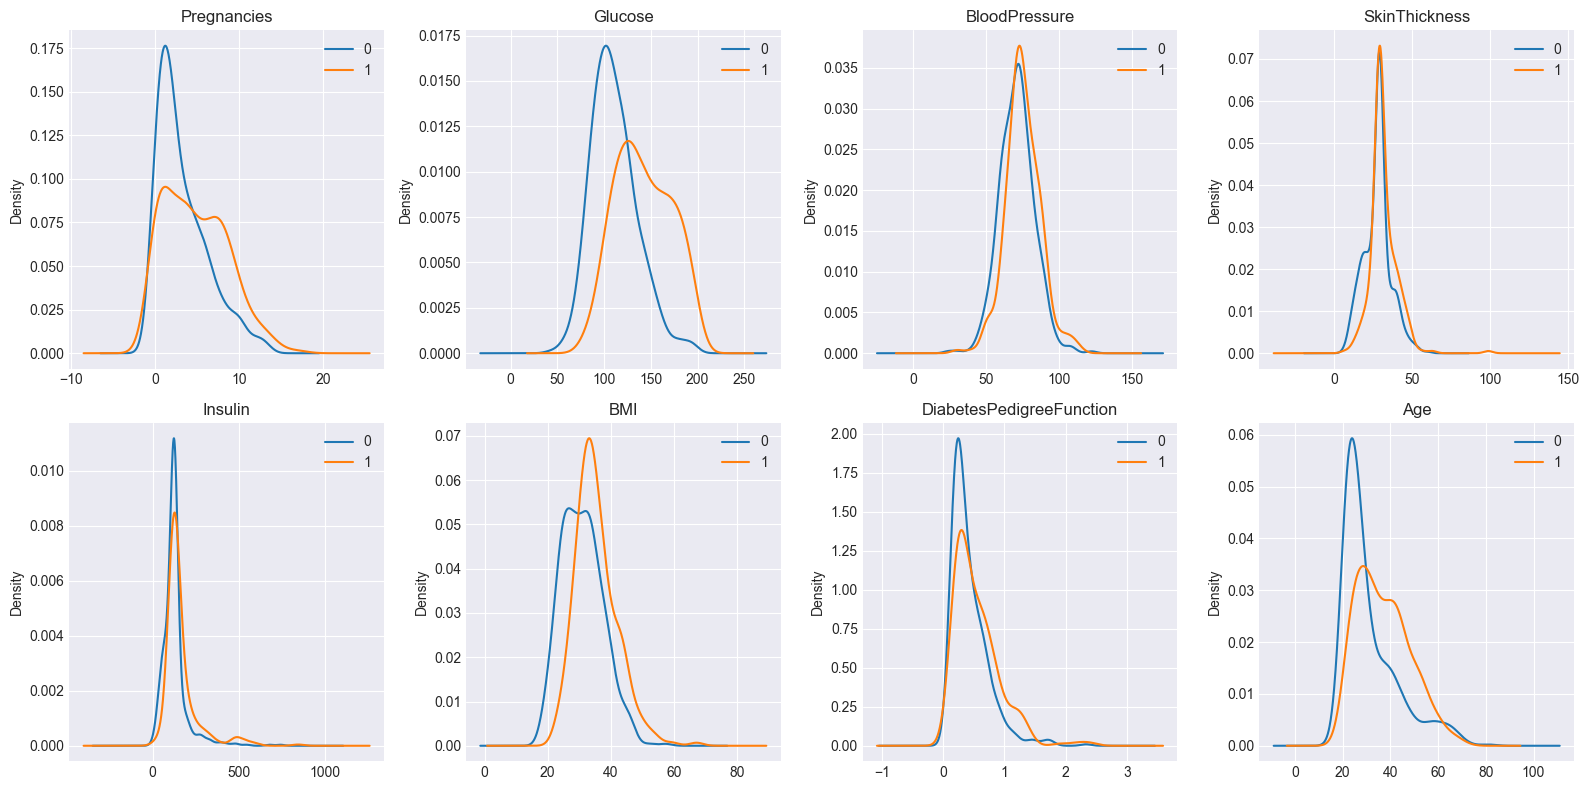

In [10]:
# Distribución de features por Outcome
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols = df_clean.columns[:-1]
for ax, col in zip(axes.flatten(), cols):
    df_clean.groupby('Outcome')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3. Split y preparación

In [11]:
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Guardar para proyectos siguientes
os.makedirs('../data/processed', exist_ok=True)
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 614 | Test: 154


## 4. Árbol de decisión

In [12]:
# Probamos las 3 funciones de criterio disponibles
criterios = ['gini', 'entropy', 'log_loss']
resultados = {}

for crit in criterios:
    arbol = DecisionTreeClassifier(criterion=crit, random_state=42)
    arbol.fit(X_train, y_train)
    acc = accuracy_score(y_test, arbol.predict(X_test))
    resultados[crit] = acc
    print(f'{crit:10s} -> Accuracy: {acc:.4f}')

gini       -> Accuracy: 0.7208
entropy    -> Accuracy: 0.7208
log_loss   -> Accuracy: 0.7208


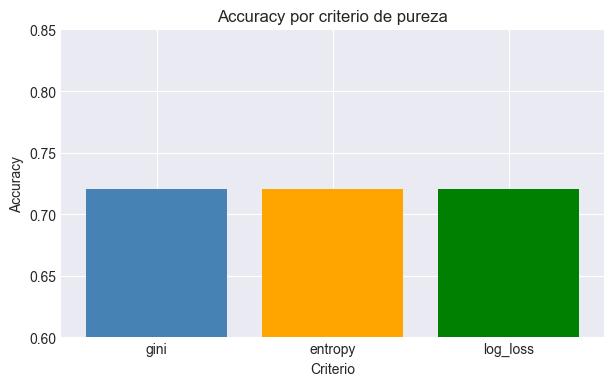

In [13]:
plt.figure(figsize=(7, 4))
plt.bar(resultados.keys(), resultados.values(), color=['steelblue', 'orange', 'green'])
plt.title('Accuracy por criterio de pureza')
plt.xlabel('Criterio')
plt.ylabel('Accuracy')
plt.ylim(0.6, 0.85)
plt.show()

## 5. Optimización con Grid Search

In [14]:
# Usamos el mejor criterio y buscamos los mejores hiperparámetros
mejor_criterio = max(resultados, key=resultados.get)
print(f'Criterio con mejor accuracy: {mejor_criterio}')

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(criterion=mejor_criterio, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print(f'Mejores parámetros: {grid.best_params_}')
print(f'Mejor accuracy en CV: {grid.best_score_:.4f}')

Criterio con mejor accuracy: gini
Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Mejor accuracy en CV: 0.7557


In [15]:
arbol_opt = grid.best_estimator_
y_pred = arbol_opt.predict(X_test)

print(f'Accuracy en test: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No diabetes', 'Diabetes']))

Accuracy en test: 0.7208

Classification Report:
              precision    recall  f1-score   support

 No diabetes       0.84      0.70      0.76        99
    Diabetes       0.58      0.76      0.66        55

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.72      0.73       154



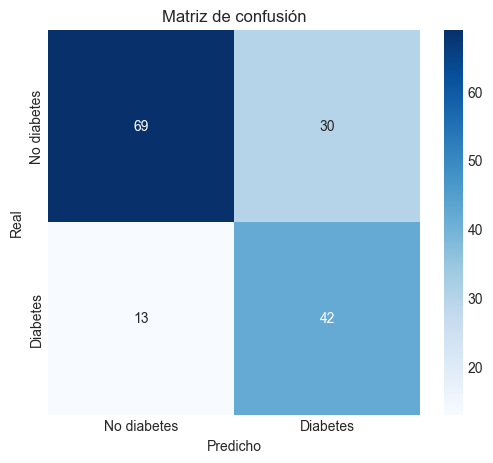

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No diabetes', 'Diabetes'],
            yticklabels=['No diabetes', 'Diabetes'])
plt.title('Matriz de confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

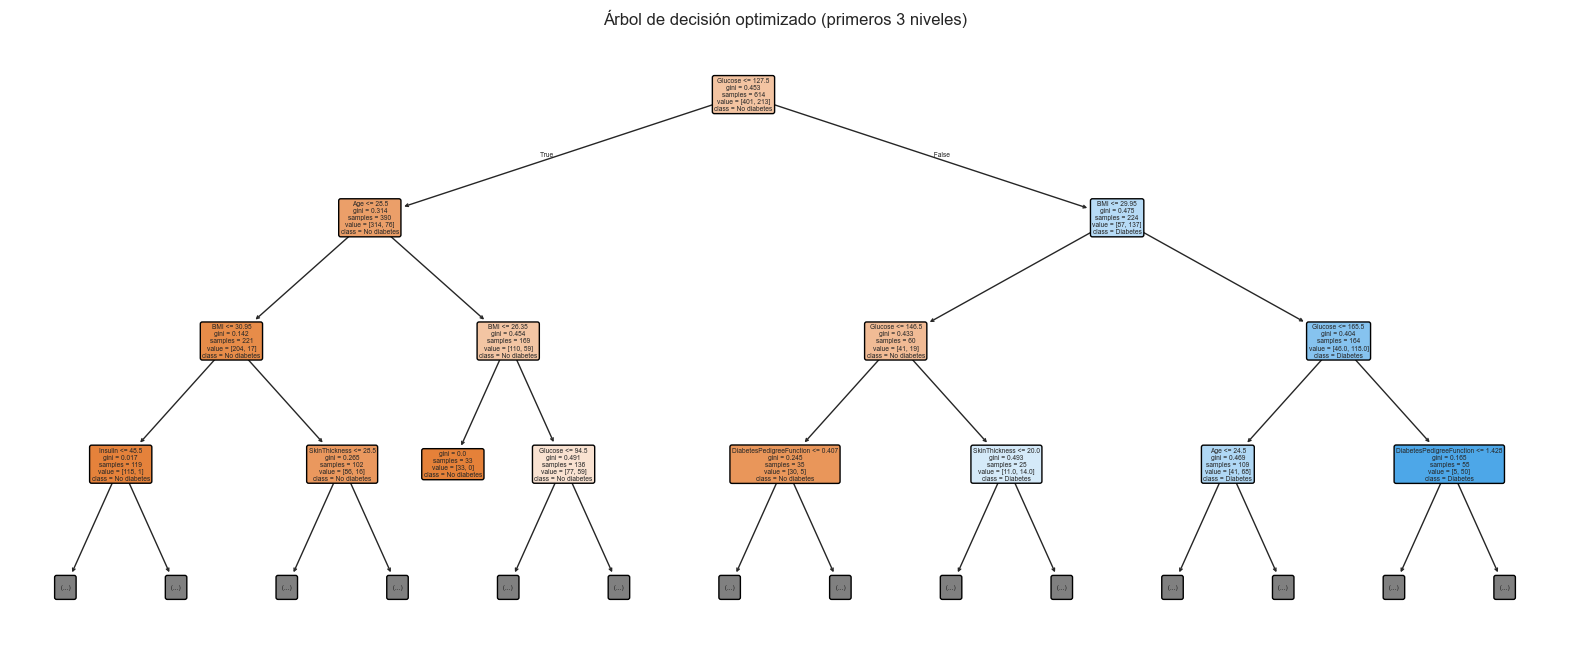

In [17]:
# Visualizar el árbol (limitado a profundidad 3 para legibilidad)
plt.figure(figsize=(20, 8))
plot_tree(arbol_opt, max_depth=3, feature_names=X.columns,
          class_names=['No diabetes', 'Diabetes'], filled=True, rounded=True)
plt.title('Árbol de decisión optimizado (primeros 3 niveles)')
plt.show()

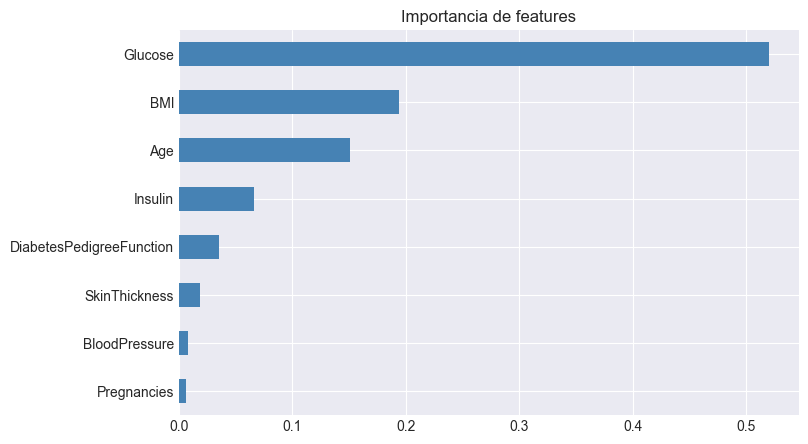

In [18]:
# Importancia de features
importancias = pd.Series(arbol_opt.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color='steelblue')
plt.title('Importancia de features')
plt.show()

## 6. Guardar el modelo

In [19]:
os.makedirs('../../models', exist_ok=True)
with open('../../models/arbol_diabetes.pkl', 'wb') as f:
    pickle.dump(arbol_opt, f)
print('Modelo guardado en models/arbol_diabetes.pkl')

Modelo guardado en models/arbol_diabetes.pkl
